In [24]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
import pycountry


In [25]:
from _helpers import mock_snakemake
snakemake = mock_snakemake(
            "collect_figures",
            scenario="default" # default, penalty-sa, penalty-ea, penalty-nwa, penalty-oc
    )

### Get regions from config

In [26]:
config = snakemake.config

In [27]:
regions = config['regions']

In [28]:
country_name_corrections = {
    "Democratic Republic of the Congo": "Congo, The Democratic Republic of the",
    "Republic of the Congo": "Republic of the Congo",
    "Kosovo": "Republic of Kosovo",  # pycountry not supported
    "Russia": "Russian Federation",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",
    "Tanzania": "United Republic of Tanzania",
    "Bolivia": "Plurinational State of Bolivia",
    "Vietnam": "Viet Nam",
    "South Korea": "Korea, Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
    "Taiwan": "Taiwan, Province of China",
    "Laos": "Lao People's Democratic Republic",
    "Brunei": "Brunei Darussalam",
    "Equatorial French Guiana": "French Guiana",
    "Syria": "Syrian Arab Republic",   
    "Palestine": "Palestine, State of",
    "Moldova": "Republic of Moldova",
}

# Apply a country name correction to the regions dict
for region, countries in regions.items():
    for i, country in enumerate(countries):
        if country in country_name_corrections:
            countries[i] = country_name_corrections[country]

### Get global map

In [29]:
# Use cartopy to get natural earth countries shapefile
shapename = 'admin_0_countries'
reader = shpreader.natural_earth(resolution='110m',
                                 category='cultural',
                                 name=shapename)

world = gpd.read_file(reader)

### Merge global dataset with regions from config

In [30]:
def country_to_iso_a2(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_2
    except LookupError:
        return None

In [31]:
# Build a mapping from country name to ISO_A2 code
country_name_to_iso = {}
for country in pycountry.countries:
    country_name_to_iso[country.name] = country.alpha_2
    # Add common names
    if hasattr(country, 'official_name'):
        country_name_to_iso[country.official_name] = country.alpha_2
        
# Build a mapping from ISO_A2 code to region
iso_to_region = {}
for region, countries in regions.items():
    for country in countries:
        # Some country names may have extra text (e.g., "Togo + Algeria"), handle them simply
        for part in country.split('+'):
            name = part.strip()
            code = country_name_to_iso.get(name)
            if code:
                iso_to_region[code] = region
            else:
                print(f"Warning: Could not find ISO_A2 code for country '{name}' in region '{region}'.")

# Fix missing ISO_A2 codes in world
world.loc[world['ISO_A2'] == '-99', 'ISO_A2'] = world.loc[world['ISO_A2'] == '-99', 'ADMIN'].apply(country_to_iso_a2)


In [32]:
world["region"] = world['ISO_A2'].map(lambda iso: iso_to_region.get(iso, 'Other'))

### Plot global map

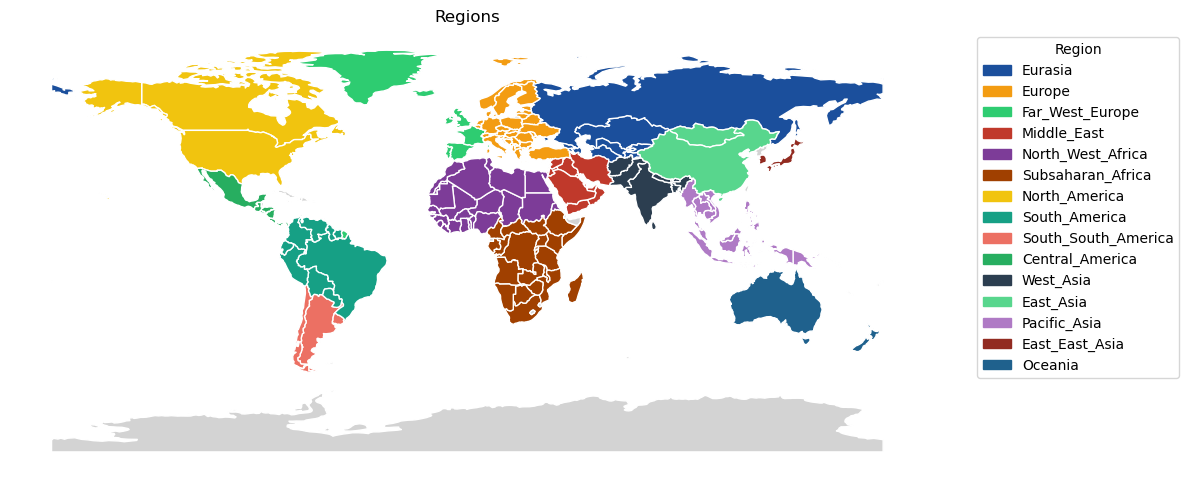

In [36]:
# Short mapping: assume config['colors'] is a dict region->color
import matplotlib.patches as mpatches

color_map = config.get('colors', {})

world['plot_color'] = world['region'].map(color_map).fillna('lightgrey')

fig, ax = plt.subplots(figsize=(12, 10))

world.plot(ax=ax, color=world['plot_color'], edgecolor='white')

# Manual legend for regions present in the map
handles = [mpatches.Patch(color=c, label=r) for r, c in color_map.items() if r in world['region'].values]
if handles:
    ax.legend(handles=handles, title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_title('Regions')
ax.axis('off')
plt.tight_layout()

plt.savefig(snakemake.input.global_map_countries)
plt.savefig(snakemake.input.global_map_countries_png, dpi=300)
plt.show()
